<h1>ACTIVITY 3 : Phillipines Dengue Cases Data Analytics Project</h1>
<hr>
<h3>Analyst : Mark John Well D. De Castro</h3>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

<hr>
<h1>Importing the Dataset</h1>

In [2]:
data = pd.read_csv('datasets\\dengue.csv')

<hr>
<h1>Checking Dataset Information</h1>

In [3]:
data

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [4]:
data.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<hr>
<h1>Adjusting the Data Type of every column</h1>

In [5]:
data['Region'] = data['Region'].astype('category')
data['Month'] = data['Month'].astype('category')
data['Year'] = data['Year'].astype('category')

<hr>
<h1>Checking for null values</h1>

In [6]:
data.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<hr>

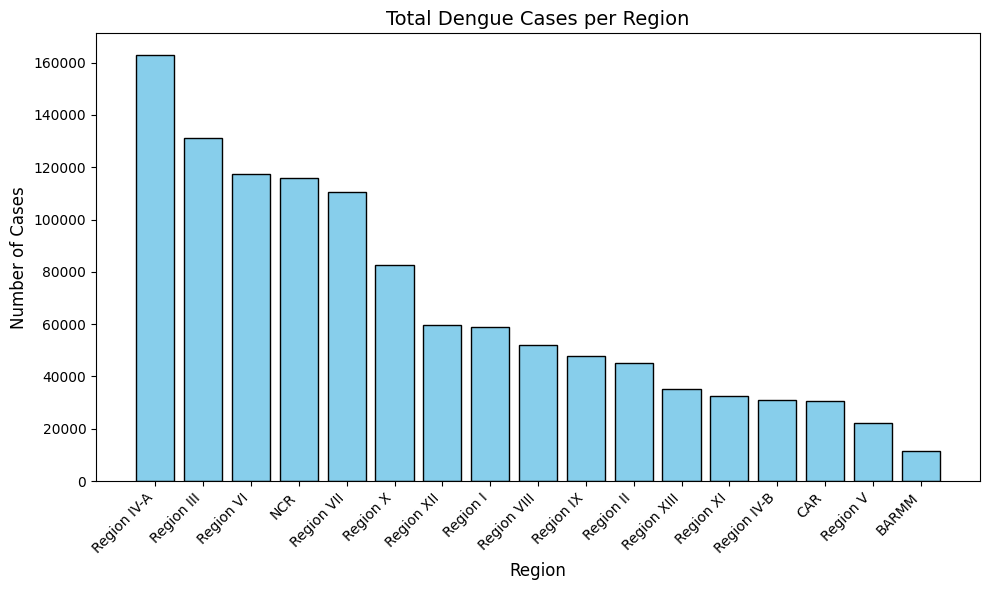

In [7]:
region_cases = data.groupby("Region")["Dengue_Cases"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(region_cases.index, region_cases.values, color="skyblue", edgecolor="black")
plt.title("Total Dengue Cases per Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Cases", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<hr>
<h1>INSIGHT 1</h1>
<h3>The bar chart shows that dengue cases vary notably across regions. Areas with higher case counts may require stronger disease prevention efforts, improved sanitation, and targeted awareness programs to reduce future outbreaks.</h3>

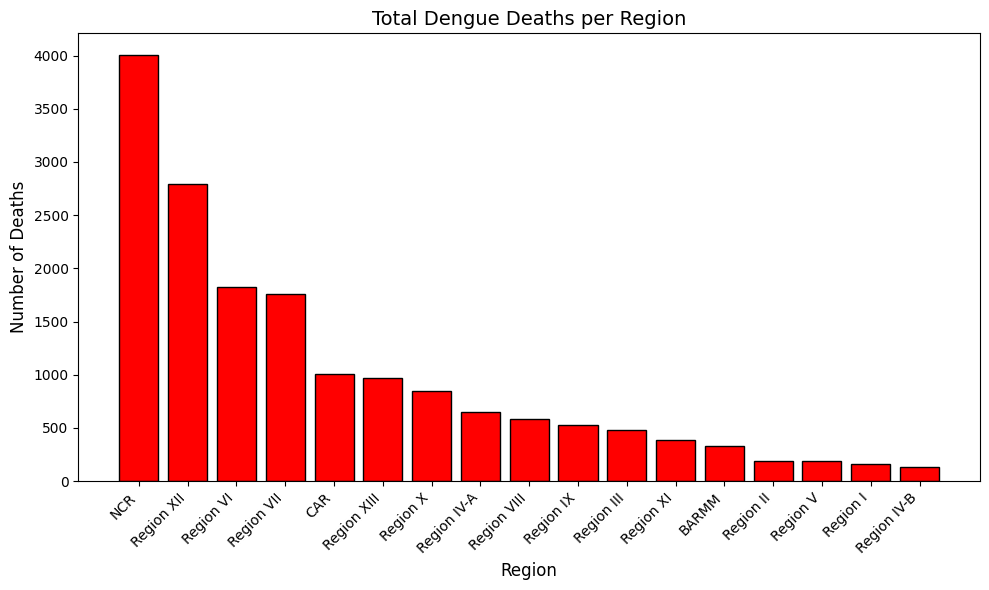

In [8]:
region_cases = data.groupby("Region")["Dengue_Deaths"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(region_cases.index, region_cases.values, color="red", edgecolor="black")
plt.title("Total Dengue Deaths per Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Deaths", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<hr>
<h1>INSIGHT 2</h1>
<h3>Despite having advanced healthcare facilities, the NCR recorded the highest number of dengue-related deaths. This may indicate that high population density and case volume can still strain medical systems, emphasizing the need for stronger prevention and early intervention efforts.</h3>

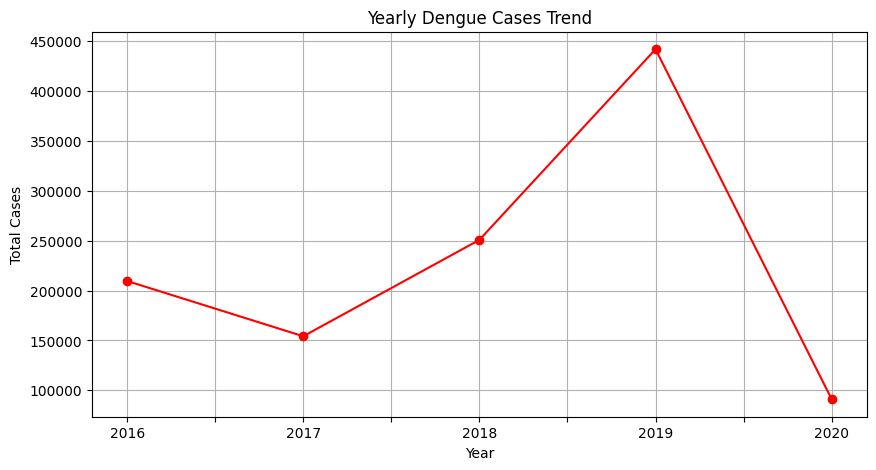

In [9]:
dengue_grouped = data.groupby("Year")["Dengue_Cases"].sum()

plt.figure(figsize=(10,5))
dengue_grouped.plot(kind="line", marker="o", color="red")
plt.title("Yearly Dengue Cases Trend")
plt.xlabel("Year")
plt.ylabel("Total Cases")
plt.grid(True)
plt.show()

<hr>
<h1>INSIGHT 3</h1>
<h3>The year 2019 recorded the highest number of dengue cases, indicating a significant outbreak that year.</h3>

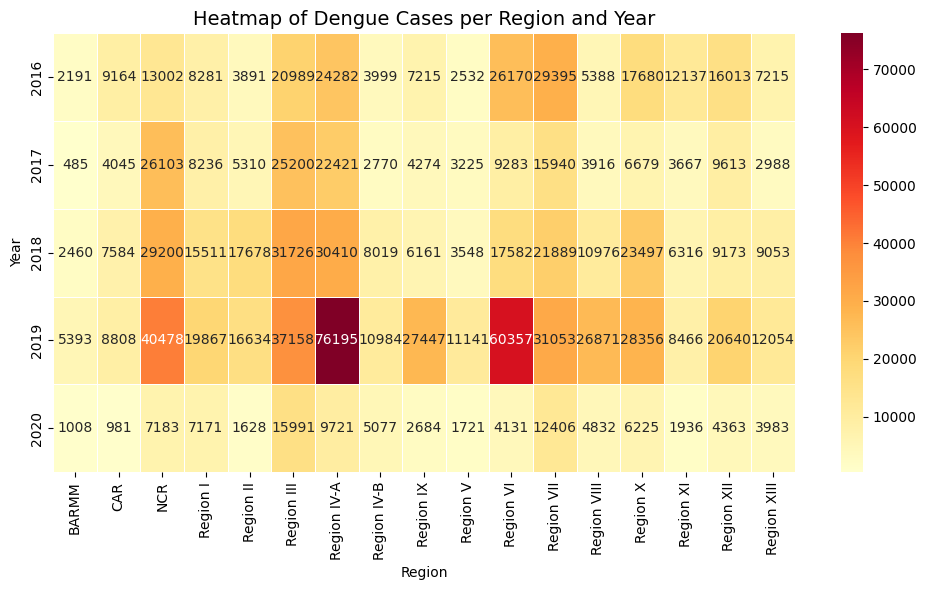

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
pivot = data.pivot_table(values="Dengue_Cases", index="Year", columns="Region", aggfunc="sum")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Heatmap of Dengue Cases per Region and Year", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

<hr>
<h1>INSIGHT 4</h1>
<h3>The heatmap shows that dengue cases fluctuate across years and regions, with certain regions experiencing higher case concentrations in specific years. This pattern suggests periodic outbreaks influenced by environmental and population factors. Regions with consistently high case counts may need sustained vector control and monitoring programs.</h3>

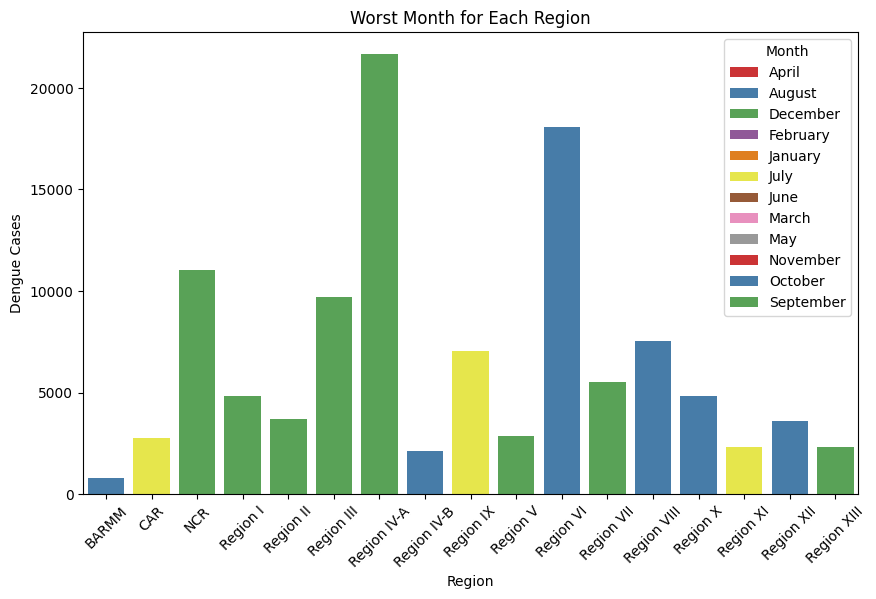

In [11]:
worst_month = data.loc[data.groupby('Region')['Dengue_Cases'].idxmax()][['Region', 'Month', 'Dengue_Cases']]
plt.figure(figsize=(10, 6))
sns.barplot(data=worst_month, x='Region', y='Dengue_Cases', hue='Month', palette='Set1')
plt.title('Worst Month for Each Region')
plt.xlabel('Region')
plt.ylabel('Dengue Cases')
plt.xticks(rotation=45)
plt.show()

<hr>
<h1>INSIGHT 5</h1>
<h3>The peak month for Dengue cases varies by region but generally falls within the rainy season (e.g., August, September). For instance, Region IV-A recorded the highest cases in September (21,658), while Region VI peaked in August (18,090). This seasonal trend underscores the impact of weather on mosquito breeding and the importance of region-specific prevention efforts during peak months.</h3>

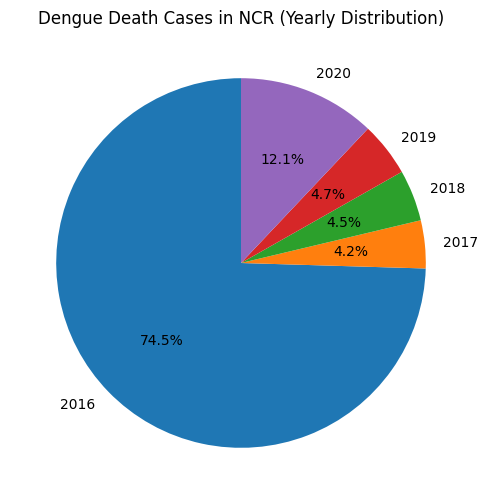

The year with the highest dengue death rates in NCR is: 2016
Number of deaths: 2987


In [12]:
ncr_data = data[data['Region'] == 'NCR']
yearly_deaths = ncr_data.groupby('Year')['Dengue_Deaths'].sum()
highest_year = yearly_deaths.idxmax()
highest_deaths = yearly_deaths.max()

plt.figure(figsize=(8, 6))
plt.pie(yearly_deaths.values, labels=yearly_deaths.index, autopct='%1.1f%%', startangle=90)
plt.title('Dengue Death Cases in NCR (Yearly Distribution)')
plt.show()
print(f"The year with the highest dengue death rates in NCR is: {highest_year}")
print(f"Number of deaths: {highest_deaths}")

<hr>
<h1>INSIGHT 6</h1>
<h3>The NCR experienced its highest Dengue death rate in 2016, with 2,987 fatalities, signaling a severe outbreak that year. This underscores the urgent need for stronger healthcare responses and preventive measures during high-risk periods, especially in densely populated urban areas like the NCR.</h3>

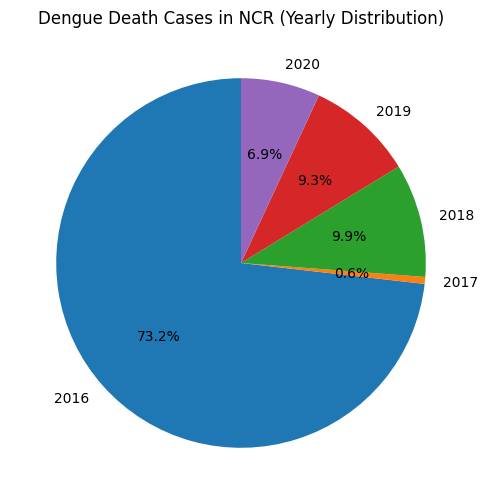

The year with the highest dengue death rates in BARMM is: 2016
Number of deaths: 243


In [13]:
ncr_data = data[data['Region'] == 'BARMM']
yearly_deaths = ncr_data.groupby('Year')['Dengue_Deaths'].sum()
highest_year = yearly_deaths.idxmax()
highest_deaths = yearly_deaths.max()

plt.figure(figsize=(8, 6))
plt.pie(yearly_deaths.values, labels=yearly_deaths.index, autopct='%1.1f%%', startangle=90)
plt.title('Dengue Death Cases in NCR (Yearly Distribution)')
plt.show()
print(f"The year with the highest dengue death rates in BARMM is: {highest_year}")
print(f"Number of deaths: {highest_deaths}")

<hr>
<h1>INSIGHT 7</h1>
<h3>The pie chart illustrates the yearly distribution of dengue-related deaths in the BARMM region. The data shows that the highest number of deaths occurred in highest year, with a total of highest deaths fatalities. This indicates a possible outbreak or increase in case severity during that year, highlighting the need for stronger public health measures, early diagnosis, and consistent mosquito control efforts in the region.</h3>

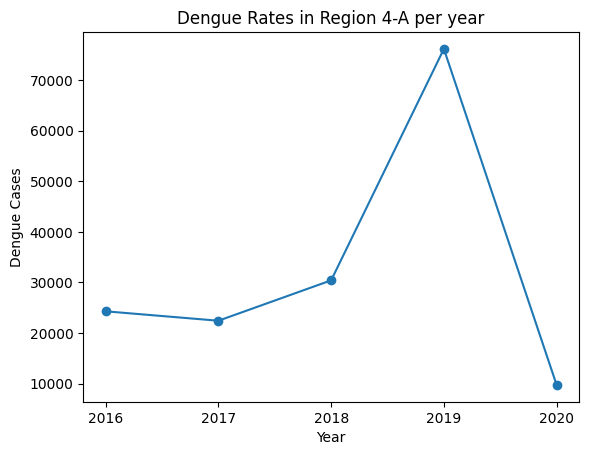

In [14]:
region_data = data[data['Region'] == 'Region IV-A']
annual_dengue_rates = region_data.groupby('Year')['Dengue_Cases'].sum()
annual_dengue_rates
years = annual_dengue_rates.index
dengue_cases = annual_dengue_rates.values
years = annual_dengue_rates.index.astype(str)
dengue_cases = annual_dengue_rates.values
plt.plot(years, dengue_cases, marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Dengue Cases')
plt.title('Dengue Rates in Region 4-A per year')
plt.show()

<hr>
<h1>INSIGHT 8</h1>
<h3>The line chart shows that dengue cases in Region IV-A fluctuate across the years, indicating recurring outbreaks rather than a steady trend. Periods of sharp increases may be linked to seasonal or environmental factors, emphasizing the need for continuous monitoring, effective vector control, and public health awareness to prevent future surges.</h3>

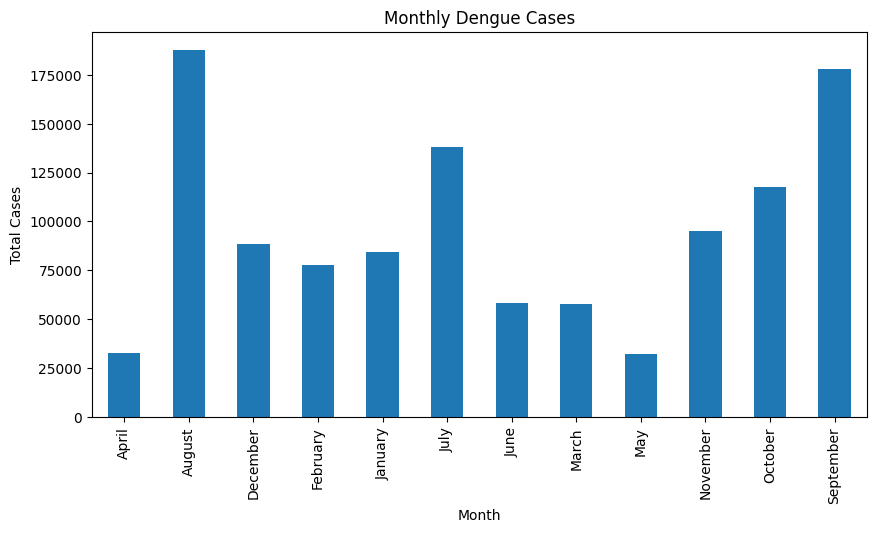

In [15]:
dengue_grouped = data.groupby("Month")["Dengue_Cases"].sum()
plt.figure(figsize=(10,5))
dengue_grouped.plot(kind="bar")
plt.title("Monthly Dengue Cases")
plt.xlabel("Month")
plt.ylabel("Total Cases")
plt.show()

<hr>
<h1>INSIGHT 9</h1>
<h3>Dengue cases peak in June to September, coinciding with the rainy season, increasing mosquito breeding and virus transmission.</h3>

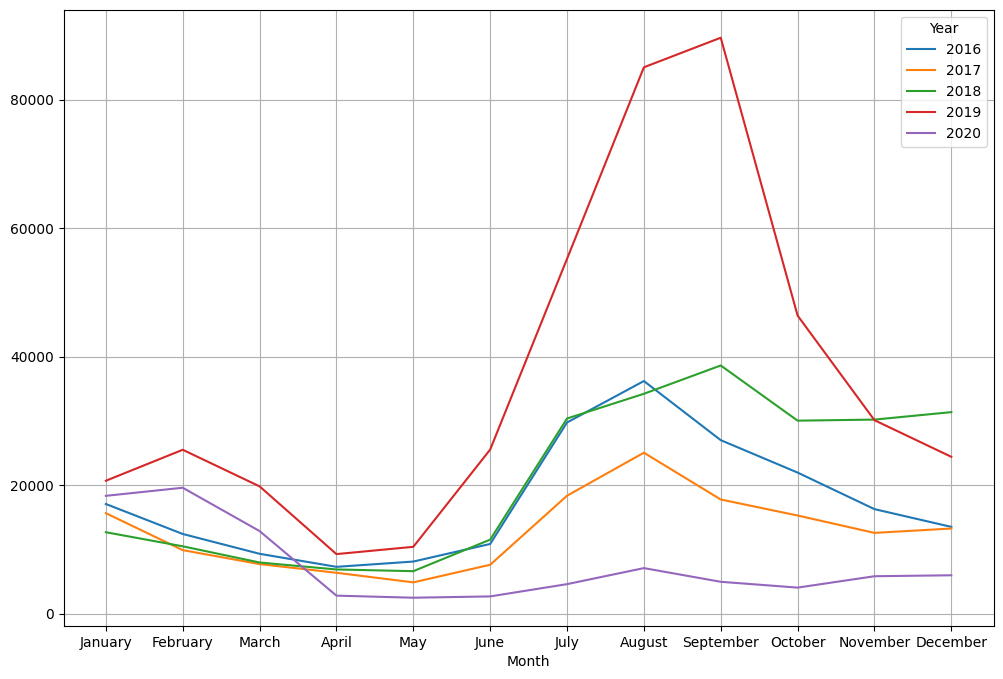

In [16]:

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
data['Month'] = pd.Categorical(data['Month'], categories=month_order, ordered=True)

monthly_cases = data.groupby([data.Month, data.Year])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='line')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

<hr>
<h1>INSIGHT 10</h1>
<h3>The line graph shows that dengue cases rise sharply from June to September, peaking during the rainy season. This trend highlights the influence of climate and mosquito breeding conditions on dengue transmission.</h3>